# House Price Prediction using Linear Regression

## Name: Harshitha R
## Internship: MainCrafts AI & ML Internship
## Task 1: Build & Evaluate a Linear Regression Model

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [4]:
# Load the dataset
df = pd.read_csv("housing.csv")

# Display the first 5 rows
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'housing.csv'

In [5]:
import os
print(os.getcwd())

C:\Users\HARSHITHA_R


In [6]:
import os
print(os.listdir())

['.anaconda', '.conda', '.continuum', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', 'anaconda3', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{fb9d4fc4-f2c7-11ef-967e-88e33ca92558}.TM.blf', 'NTUSER.DAT{fb9d4fc4-f2c7-11ef-967e-88e33ca92558}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{fb9d4fc4-f2c7-11ef-967e-88e33ca92558}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'PycharmProjects', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'task1_ml_linear_regression.ipynb', 'Templates', 'Untitled Folder', 'Videos']


In [7]:
import os

os.listdir("C:\\Users\\Harshitha_R")


['.anaconda',
 '.conda',
 '.continuum',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 'anaconda3',
 'AppData',
 'Application Data',
 'Contacts',
 'Cookies',
 'Documents',
 'Downloads',
 'Favorites',
 'Links',
 'Local Settings',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{fb9d4fc4-f2c7-11ef-967e-88e33ca92558}.TM.blf',
 'NTUSER.DAT{fb9d4fc4-f2c7-11ef-967e-88e33ca92558}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{fb9d4fc4-f2c7-11ef-967e-88e33ca92558}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'PrintHood',
 'PycharmProjects',
 'Recent',
 'Saved Games',
 'Searches',
 'SendTo',
 'Start Menu',
 'task1_ml_linear_regression.ipynb',
 'Templates',
 'Untitled Folder',
 'Videos']

In [8]:
import os

for root, dirs, files in os.walk(r"C:\Users\Harshitha_R"):
    for file in files:
        if "housing" in file.lower():
            print(os.path.join(root, file))

C:\Users\Harshitha_R\anaconda3\Lib\site-packages\sklearn\datasets\_california_housing.py
C:\Users\Harshitha_R\anaconda3\Lib\site-packages\sklearn\datasets\descr\california_housing.rst
C:\Users\Harshitha_R\anaconda3\Lib\site-packages\sklearn\datasets\tests\test_california_housing.py
C:\Users\Harshitha_R\anaconda3\Lib\site-packages\sklearn\datasets\tests\__pycache__\test_california_housing.cpython-313.pyc
C:\Users\Harshitha_R\anaconda3\Lib\site-packages\sklearn\datasets\__pycache__\_california_housing.cpython-313.pyc
C:\Users\Harshitha_R\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\tests\results\housing-data.csv
C:\Users\Harshitha_R\anaconda3\pkgs\scikit-learn-1.7.2-py313h7f7e138_0\Lib\site-packages\sklearn\datasets\_california_housing.py
C:\Users\Harshitha_R\anaconda3\pkgs\scikit-learn-1.7.2-py313h7f7e138_0\Lib\site-packages\sklearn\datasets\descr\california_housing.rst
C:\Users\Harshitha_R\anaconda3\pkgs\scikit-learn-1.7.2-py313h7f7e138_0\Lib\site-packages\sklearn\datasets\t

In [9]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Harshitha_R\Downloads\ML_Task1\housing.csv\housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [11]:
df.isnull().sum()


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [12]:
df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)

C:\Users\HARSHITHA_R\AppData\Local\Temp\ipykernel_20304\2164095440.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)


In [13]:
# Handle missing values in total_bedrooms
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

# Check if any missing values remain
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [14]:
# Separate features and target variable

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

# Display first 5 rows of features
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY


In [15]:
# Convert categorical column into numerical values

X = pd.get_dummies(X, drop_first=True)

# Display the updated features
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,False,False,True,False


In [16]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

# Check the shape of the split data
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16512, 12)
X_test: (4128, 12)
y_train: (16512,)
y_test: (4128,)


In [17]:
# Train Linear Regression Model

from sklearn.linear_model import LinearRegression

model = LinearRegression()

# Fit the model using training data
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [18]:
# Make predictions on test data

y_pred = model.predict(X_test)

# Display first 5 predictions
y_pred[:5]

array([ 54055.44889898, 124225.33893718, 255489.37949165, 268002.43156919,
       262769.43481569])

In [19]:
# Evaluate the model performance

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 50670.738240971994
Mean Squared Error (MSE): 4908476721.156587
R2 Score: 0.6254240620553628


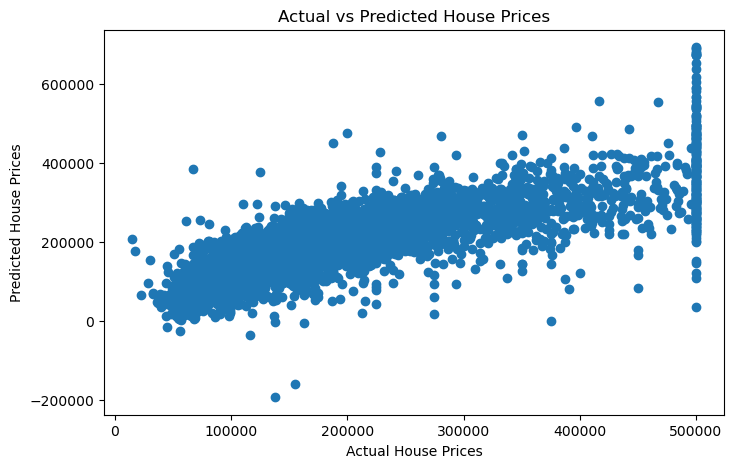

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

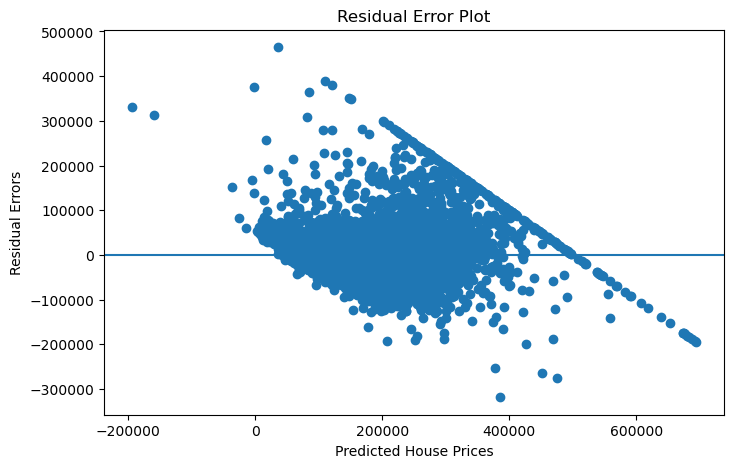

In [21]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals)

plt.xlabel("Predicted House Prices")
plt.ylabel("Residual Errors")
plt.title("Residual Error Plot")

plt.axhline(y=0)

plt.show()

In [22]:
import pickle

# Save the trained model
with open("linear_regression_house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


In [1]:
import os

print(os.getcwd())

C:\Users\HARSHITHA_R
